Code — Everything in One Training Lab

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

# ── Dataset ────────────────────────────────────────────────────────────────
X_np, y_np = make_moons(n_samples=2000, noise=0.25, random_state=42)
X_np = StandardScaler().fit_transform(X_np).astype(np.float32)
y_np = y_np.reshape(-1, 1).astype(np.float32)

X_tr, X_te, y_tr, y_te = train_test_split(X_np, y_np, test_size=0.2)

X_train = torch.tensor(X_tr); y_train = torch.tensor(y_tr)
X_test  = torch.tensor(X_te); y_test  = torch.tensor(y_te)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: torch.Size([1600, 2]) | Test: torch.Size([400, 2])


Section A — Loss functions compared


SECTION A: Loss functions — see the difference


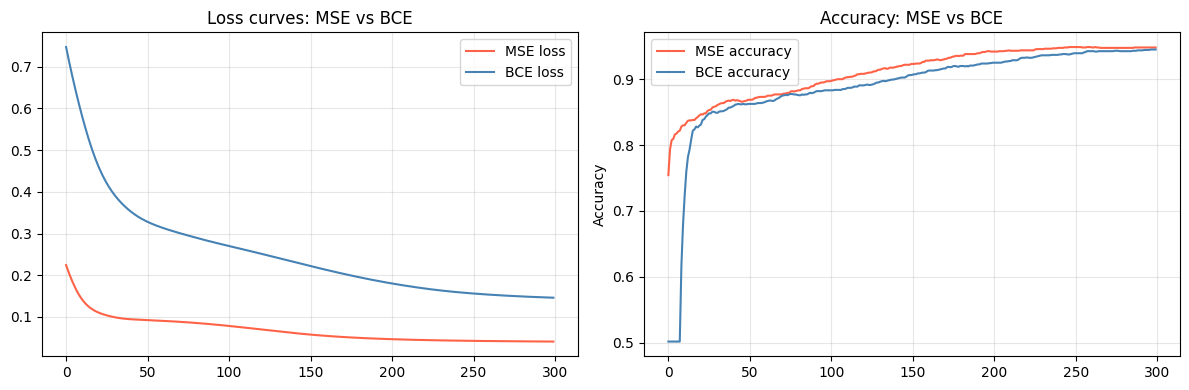


Final accuracy — MSE: 94.8% | BCE: 94.5%
BCE should win. Wrong loss = wrong gradients.

── Multi-class with CrossEntropyLoss ──
CrossEntropyLoss on logits: 0.7714
Probabilities shape: torch.Size([1600, 2])
Sample probs (should sum to 1): [0.541 0.459]
Sum check: 1.0000


In [2]:
print("=" * 55)
print("SECTION A: Loss functions — see the difference")
print("=" * 55)

# ── MSE on a classification problem (wrong choice) ──
model_mse = nn.Sequential(
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 1), nn.Sigmoid()
)

# ── BCE (correct choice) ──
model_bce = nn.Sequential(
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 1), nn.Sigmoid()
)

# Same architecture, only loss differs
def train_model(model, loss_fn, epochs=300, lr=0.01):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses, accs = [], []
    for _ in range(epochs):
        pred = model(X_train)
        loss = loss_fn(pred, y_train)
        opt.zero_grad(); loss.backward(); opt.step()
        with torch.no_grad():
            acc = ((pred > 0.5) == y_train).float().mean().item()
        losses.append(loss.item()); accs.append(acc)
    return losses, accs

losses_mse, accs_mse = train_model(model_mse, nn.MSELoss())
losses_bce, accs_bce = train_model(model_bce, nn.BCELoss())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses_mse, label='MSE loss',  color='tomato')
axes[0].plot(losses_bce, label='BCE loss',  color='steelblue')
axes[0].set_title("Loss curves: MSE vs BCE")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(accs_mse, label='MSE accuracy', color='tomato')
axes[1].plot(accs_bce, label='BCE accuracy', color='steelblue')
axes[1].set_title("Accuracy: MSE vs BCE")
axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nFinal accuracy — MSE: {accs_mse[-1]*100:.1f}% | BCE: {accs_bce[-1]*100:.1f}%")
print("BCE should win. Wrong loss = wrong gradients.")

# ── Multi-class cross-entropy ──
print("\n── Multi-class with CrossEntropyLoss ──")
# Important: CrossEntropyLoss = LogSoftmax + NLLLoss
# It expects RAW LOGITS (no softmax before it)
model_mc = nn.Sequential(
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 2)              # 2 classes, NO sigmoid/softmax here
)
X_mc = X_train
y_mc = y_train.long().squeeze(1)  # CrossEntropyLoss wants Long ints, shape (N,)

criterion_mc = nn.CrossEntropyLoss()
pred_logits  = model_mc(X_mc)     # shape: (N, 2)
loss_mc      = criterion_mc(pred_logits, y_mc)
print(f"CrossEntropyLoss on logits: {loss_mc.item():.4f}")

# Get probabilities if you need them (e.g. for inference)
probs = torch.softmax(pred_logits, dim=1)
print(f"Probabilities shape: {probs.shape}")
print(f"Sample probs (should sum to 1): {probs[0].detach().numpy().round(3)}")
print(f"Sum check: {probs[0].sum().item():.4f}")

Section B — Optimizers compared



SECTION B: Optimizers — same model, different paths
SGD lr=0.1             | final loss: 0.2422 | acc: 90.8%
SGD+momentum           | final loss: 0.1286 | acc: 95.2%
RMSProp                | final loss: 0.1296 | acc: 95.2%
Adam lr=0.01           | final loss: 0.1238 | acc: 95.2%
Adam lr=0.001          | final loss: 0.1601 | acc: 94.0%


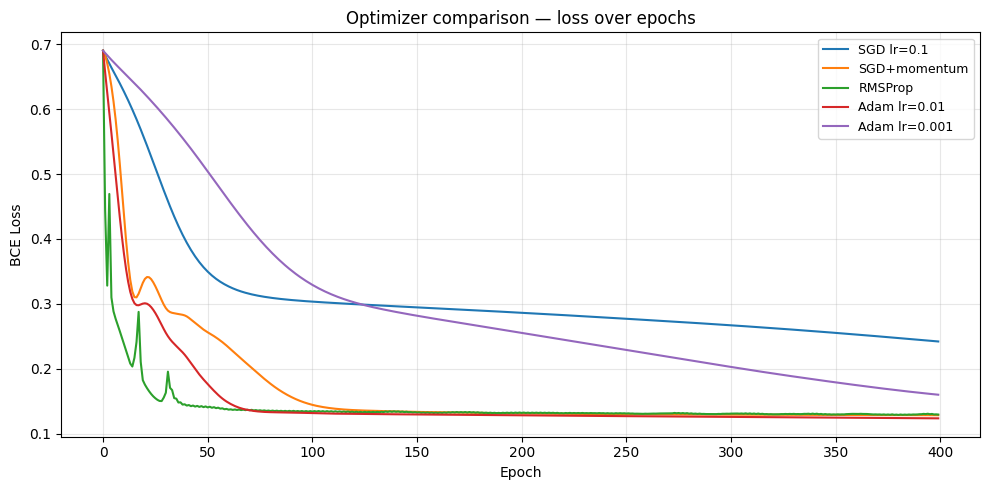

In [3]:
print("\n" + "=" * 55)
print("SECTION B: Optimizers — same model, different paths")
print("=" * 55)

def make_model():
    torch.manual_seed(0)
    return nn.Sequential(
        nn.Linear(2, 32), nn.ReLU(),
        nn.Linear(32, 16), nn.ReLU(),
        nn.Linear(16, 1), nn.Sigmoid()
    )

configs = [
    ("SGD lr=0.1",       torch.optim.SGD,     {"lr": 0.1}),
    ("SGD+momentum",     torch.optim.SGD,     {"lr": 0.1, "momentum": 0.9}),
    ("RMSProp",          torch.optim.RMSprop, {"lr": 0.01}),
    ("Adam lr=0.01",     torch.optim.Adam,    {"lr": 0.01}),
    ("Adam lr=0.001",    torch.optim.Adam,    {"lr": 0.001}),
]

results = {}
for name, OptClass, kwargs in configs:
    model = make_model()
    opt   = OptClass(model.parameters(), **kwargs)
    crit  = nn.BCELoss()
    history = []
    for epoch in range(400):
        pred = model(X_train)
        loss = crit(pred, y_train)
        opt.zero_grad(); loss.backward(); opt.step()
        history.append(loss.item())
    results[name] = history
    final_acc = ((model(X_train).detach() > 0.5) == y_train).float().mean() * 100
    print(f"{name:22s} | final loss: {history[-1]:.4f} | acc: {final_acc:.1f}%")

plt.figure(figsize=(10, 5))
for name, hist in results.items():
    plt.plot(hist, label=name, linewidth=1.5)
plt.title("Optimizer comparison — loss over epochs")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.legend(fontsize=9); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Section C — Learning rate: the most important hyperparameter



SECTION C: Learning rate — too high, too low, just right


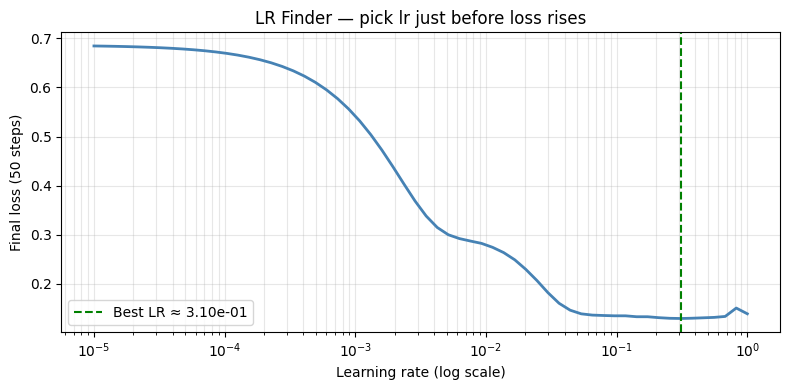


Suggested learning rate: 3.10e-01
Rule of thumb: use 10× smaller than the minimum for stable training


In [4]:
print("\n" + "=" * 55)
print("SECTION C: Learning rate — too high, too low, just right")
print("=" * 55)

# The learning rate finder idea: start tiny, increase exponentially, plot loss
# When loss stops dropping and starts rising → you found the best lr region

lr_values = np.logspace(-5, 0, 60)   # 1e-5 to 1.0
lr_losses  = []

for lr in lr_values:
    torch.manual_seed(0)
    m   = nn.Sequential(nn.Linear(2,32), nn.ReLU(), nn.Linear(32,1), nn.Sigmoid())
    opt = torch.optim.Adam(m.parameters(), lr=float(lr))
    crit = nn.BCELoss()
    # Train for just 50 steps — enough to see the trend
    for _ in range(50):
        pred = m(X_train)
        loss = crit(pred, y_train)
        opt.zero_grad(); loss.backward(); opt.step()
    lr_losses.append(loss.item())

plt.figure(figsize=(8, 4))
plt.semilogx(lr_values, lr_losses, color='steelblue', linewidth=2)
plt.axvline(x=lr_values[np.argmin(lr_losses)], color='green', linestyle='--',
            label=f"Best LR ≈ {lr_values[np.argmin(lr_losses)]:.2e}")
plt.xlabel("Learning rate (log scale)"); plt.ylabel("Final loss (50 steps)")
plt.title("LR Finder — pick lr just before loss rises")
plt.legend(); plt.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

best_lr = lr_values[np.argmin(lr_losses)]
print(f"\nSuggested learning rate: {best_lr:.2e}")
print("Rule of thumb: use 10× smaller than the minimum for stable training")

Section D — Learning rate schedulers



SECTION D: LR Schedulers — decay the rate as you converge


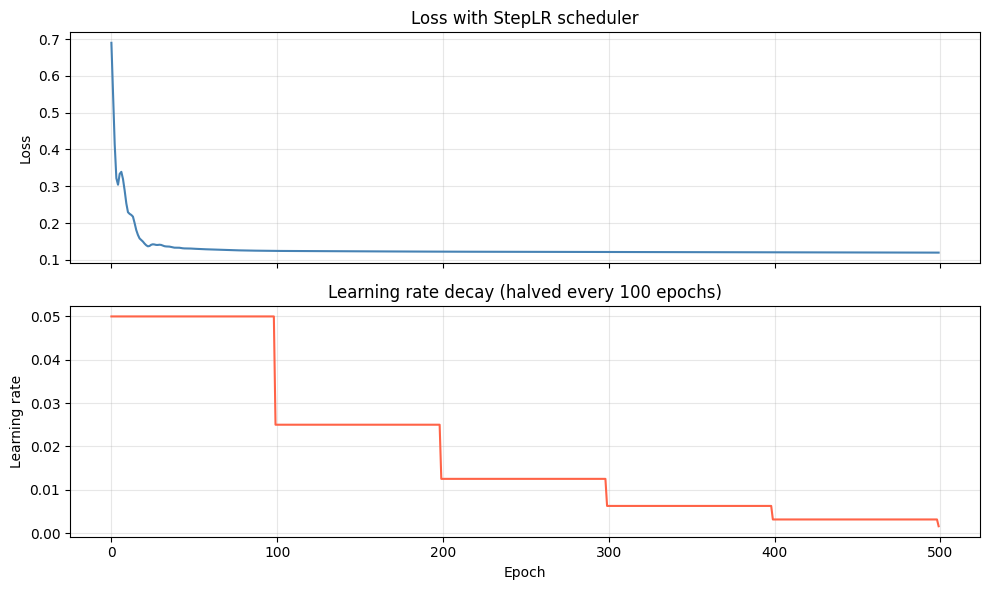


Other schedulers to know:
  CosineAnnealingLR — smoothly decays to near-zero, then resets
  ReduceLROnPlateau — cuts lr when validation loss stops improving
  OneCycleLR        — warmup + decay in one cycle (state-of-the-art for CV)


In [5]:
print("\n" + "=" * 55)
print("SECTION D: LR Schedulers — decay the rate as you converge")
print("=" * 55)

# Why schedulers? Start with a large lr to explore, shrink it to fine-tune
# Common analogy: land a plane — fast approach, slow touchdown

torch.manual_seed(0)
model_sched = nn.Sequential(
    nn.Linear(2,32), nn.ReLU(),
    nn.Linear(32,16), nn.ReLU(),
    nn.Linear(16,1), nn.Sigmoid()
)
optimizer = torch.optim.Adam(model_sched.parameters(), lr=0.05)

# StepLR: multiply lr by gamma every step_size epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
# Every 100 epochs, lr = lr * 0.5

crit = nn.BCELoss()
losses_sched, lr_track = [], []

for epoch in range(500):
    pred = model_sched(X_train)
    loss = crit(pred, y_train)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    scheduler.step()   # ← update the lr after each epoch

    losses_sched.append(loss.item())
    lr_track.append(optimizer.param_groups[0]['lr'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(losses_sched, color='steelblue', linewidth=1.5)
ax1.set_ylabel("Loss"); ax1.set_title("Loss with StepLR scheduler")
ax1.grid(True, alpha=0.3)

ax2.plot(lr_track, color='tomato', linewidth=1.5)
ax2.set_ylabel("Learning rate"); ax2.set_xlabel("Epoch")
ax2.set_title("Learning rate decay (halved every 100 epochs)")
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Other useful schedulers:
print("\nOther schedulers to know:")
print("  CosineAnnealingLR — smoothly decays to near-zero, then resets")
print("  ReduceLROnPlateau — cuts lr when validation loss stops improving")
print("  OneCycleLR        — warmup + decay in one cycle (state-of-the-art for CV)")

Section E — Vanishing gradients: measure it live


In [6]:
print("\n" + "=" * 55)
print("SECTION E: Measure vanishing gradients yourself")
print("=" * 55)

def get_grad_stats(model, X, y, criterion):
    """Train one step and return gradient magnitude per layer."""
    pred = model(X)
    loss = criterion(pred, y)
    loss.zero_grad() if hasattr(loss, 'zero_grad') else None

    # Clear existing grads
    for p in model.parameters():
        if p.grad is not None: p.grad.zero_()

    loss.backward()
    stats = {}
    for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
            stats[name] = param.grad.abs().mean().item()
    return stats

# Deep sigmoid network
deep_sigmoid = nn.Sequential(
    nn.Linear(2,16),  nn.Sigmoid(),
    nn.Linear(16,16), nn.Sigmoid(),
    nn.Linear(16,16), nn.Sigmoid(),
    nn.Linear(16,16), nn.Sigmoid(),
    nn.Linear(16,1),  nn.Sigmoid(),
)

# Deep ReLU network
deep_relu = nn.Sequential(
    nn.Linear(2,16),  nn.ReLU(),
    nn.Linear(16,16), nn.ReLU(),
    nn.Linear(16,16), nn.ReLU(),
    nn.Linear(16,16), nn.ReLU(),
    nn.Linear(16,1),  nn.Sigmoid(),  # keep sigmoid at output for BCE
)

crit = nn.BCELoss()

sig_grads  = get_grad_stats(deep_sigmoid, X_train, y_train, crit)
relu_grads = get_grad_stats(deep_relu,    X_train, y_train, crit)

print("\nGradient magnitudes — Sigmoid network:")
for name, val in sig_grads.items():
    bar = "█" * max(1, int(val * 5000))
    print(f"  {name:30s}: {val:.2e}  {bar}")

print("\nGradient magnitudes — ReLU network:")
for name, val in relu_grads.items():
    bar = "█" * max(1, int(val * 100))
    print(f"  {name:30s}: {val:.2e}  {bar}")

print("\nNotice: sigmoid gradients shrink exponentially toward first layers.")
print("ReLU gradients stay roughly consistent. This is why ReLU unlocked deep learning.")


SECTION E: Measure vanishing gradients yourself

Gradient magnitudes — Sigmoid network:
  0.weight                      : 1.87e-05  █
  2.weight                      : 3.02e-05  █
  4.weight                      : 4.88e-05  █
  6.weight                      : 3.95e-04  █
  8.weight                      : 1.70e-02  ████████████████████████████████████████████████████████████████████████████████████

Gradient magnitudes — ReLU network:
  0.weight                      : 1.58e-03  █
  2.weight                      : 6.43e-04  █
  4.weight                      : 5.88e-04  █
  6.weight                      : 6.78e-04  █
  8.weight                      : 2.68e-03  █

Notice: sigmoid gradients shrink exponentially toward first layers.
ReLU gradients stay roughly consistent. This is why ReLU unlocked deep learning.


Section F — Weight initialisation matters



SECTION F: Weight initialisation — start from a good place


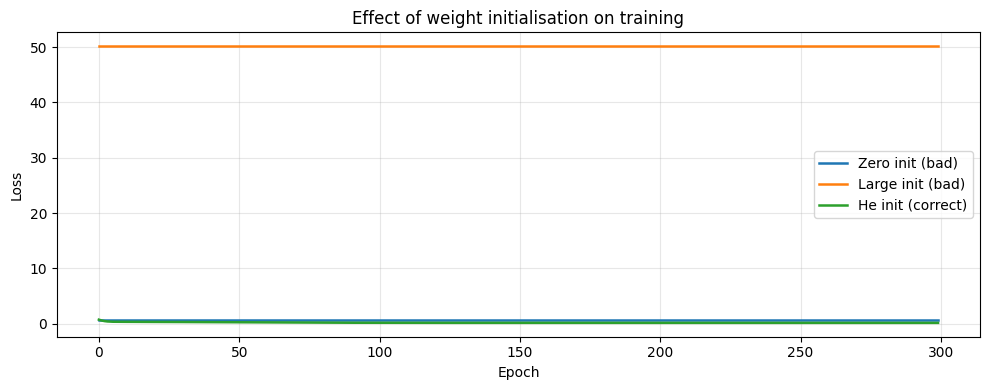


Zero init: all neurons learn identically — symmetry problem
Large init: activations explode or vanish from the start
He init: variance scaled to layer size — gradients flow well


In [7]:
print("\n" + "=" * 55)
print("SECTION F: Weight initialisation — start from a good place")
print("=" * 55)

# Bad init: all zeros
def zeros_init(m):
    if isinstance(m, nn.Linear):
        nn.init.zeros_(m.weight)
        nn.init.zeros_(m.bias)

# Bad init: too large
def large_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, std=10.0)

# Good init: He (Kaiming) for ReLU
def he_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)

init_configs = [
    ("Zero init (bad)",  zeros_init),
    ("Large init (bad)", large_init),
    ("He init (correct)", he_init),
]

plt.figure(figsize=(10, 4))
for label, init_fn in init_configs:
    torch.manual_seed(0)
    m = nn.Sequential(
        nn.Linear(2,32), nn.ReLU(),
        nn.Linear(32,16), nn.ReLU(),
        nn.Linear(16,1), nn.Sigmoid()
    )
    m.apply(init_fn)
    opt = torch.optim.Adam(m.parameters(), lr=0.01)
    hist = []
    for _ in range(300):
        p = m(X_train); l = crit(p, y_train)
        opt.zero_grad(); l.backward(); opt.step()
        hist.append(l.item())
    plt.plot(hist, label=label, linewidth=1.8)

plt.title("Effect of weight initialisation on training")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\nZero init: all neurons learn identically — symmetry problem")
print("Large init: activations explode or vanish from the start")
print("He init: variance scaled to layer size — gradients flow well")

Section G — Mini-batch training with DataLoader


In [8]:
print("\n" + "=" * 55)
print("SECTION G: DataLoader — how real training works")
print("=" * 55)

from torch.utils.data import TensorDataset, DataLoader

# Wrap data in a Dataset and DataLoader
dataset    = TensorDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"Total samples:  {len(dataset)}")
print(f"Batch size:     32")
print(f"Batches/epoch:  {len(dataloader)}")

torch.manual_seed(0)
model_dl = nn.Sequential(
    nn.Linear(2,32), nn.ReLU(),
    nn.Linear(32,16), nn.ReLU(),
    nn.Linear(16,1), nn.Sigmoid()
)
opt  = torch.optim.Adam(model_dl.parameters(), lr=0.01)
crit = nn.BCELoss()

for epoch in range(10):
    epoch_loss = 0
    for batch_X, batch_y in dataloader:   # iterate mini-batches
        pred  = model_dl(batch_X)
        loss  = crit(pred, batch_y)
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()

    if epoch % 2 == 0:
        avg = epoch_loss / len(dataloader)
        print(f"Epoch {epoch} | avg batch loss: {avg:.4f}")

print("\nWhy mini-batches?")
print("  Full batch: accurate gradient but slow, huge memory")
print("  Mini-batch: noisy but fast, fits GPU memory, trains well")
print("  Batch size 32-256 is standard. Larger = more stable but needs more memory.")


SECTION G: DataLoader — how real training works
Total samples:  1600
Batch size:     32
Batches/epoch:  50
Epoch 0 | avg batch loss: 0.3575
Epoch 2 | avg batch loss: 0.1701
Epoch 4 | avg batch loss: 0.1485
Epoch 6 | avg batch loss: 0.1581
Epoch 8 | avg batch loss: 0.1496

Why mini-batches?
  Full batch: accurate gradient but slow, huge memory
  Mini-batch: noisy but fast, fits GPU memory, trains well
  Batch size 32-256 is standard. Larger = more stable but needs more memory.
